# Definindo Parâmetros

## Modelo: Random Forest

O objetivo desse notebook é analisar o funcionamento do modelo de classificação Random Forest para definir o gênero de uma música com base nas suas audio features

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import os
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

## Leitura dos Dados

In [2]:
caminho_arquivo = '../data/spotify_songs.csv'

df = pd.read_csv(caminho_arquivo)

features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'explicit', 'tempo']

## Limpeza do Dataset: removendo duplicatas

In [3]:
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

df = df_limpo.copy()

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


## Normalizando a matriz das features

In [4]:
# Selecionamos as colunas das audio features que importam
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Aplicando a clusterização: K-Means

Resolvemos aplicar o modelo não supervisionado K-means para organizar nossas músicas em grupos com base nas suas audio features, uma vez que se considerássemos apenas a coluna `track_genre` para fazermos nossa classificação o modelo teria que lidar com 114 classes e apresentaria baixos valores de f1-score e acurácia.

In [5]:
print("Treinando o K-Means...")
kmeans = KMeans(n_clusters=15, random_state=42, n_init='auto')
df['macrogenero'] = kmeans.fit_predict(X_scaled)

print("Clusterização concluída! Nova coluna 'macrogenero' criada.")

Treinando o K-Means...
Clusterização concluída! Nova coluna 'macrogenero' criada.


## Random Forest

In [83]:
# Separando em Treino e Teste (80% para treinar, 20% para testar)
X_train, X_test, y_train, y_test = train_test_split(
    X, df['macrogenero'], test_size=0.2, random_state=42
)


param_grid_rf = {
    'n_estimators': [100, 200, 300],       
    'max_depth': [10, 20, 30, 40],          
    'min_samples_split': [2, 5, 10],      
    'class_weight': ['balanced', 'balanced_subsample'] 
}

rf_base = RandomForestClassifier(random_state=42)

buscador_rf = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=2 
)


print("Iniciando a busca pelos melhores hiperparâmetros da Floresta Aleatória...")
buscador_rf.fit(X_train, y_train)

print(f"A melhor combinação encontrada foi: {buscador_rf.best_params_}")
print(f"O melhor F1-Score obtido nos testes foi: {buscador_rf.best_score_:.2f}")

melhor_modelo_rf = buscador_rf.best_estimator_

Iniciando a busca pelos melhores hiperparâmetros da Floresta Aleatória...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
A melhor combinação encontrada foi: {'class_weight': 'balanced_subsample', 'max_depth': 40, 'min_samples_split': 2, 'n_estimators': 300}
O melhor F1-Score obtido nos testes foi: 0.95


In [96]:
# Criamos um dicionário vazio para guardar nossos modelos E nossos scalers correspondentes
especialistas = {}

todas_as_vibes = df['macrogenero'].unique()

print("Treinando os Especialistas Lineares (Regressão Logística com Filtro de Ruído)...\n")

# Variável de controle: Um gênero precisa ter pelo menos 15 músicas 
# dentro de um cluster para ser levado a sério pelo especialista
MIN_MUSICAS_POR_GENERO = 15

for vibe in todas_as_vibes:
    df_vibe = df[df['macrogenero'] == vibe]
    
    # Realizamos o filtro dentro do cluster para remover ruídos e gêneros raros
    contagem = df_vibe['track_genre'].value_counts()
    generos_fortes = contagem[contagem >= MIN_MUSICAS_POR_GENERO].index
    df_vibe_limpo = df_vibe[df_vibe['track_genre'].isin(generos_fortes)]

    if len(df_vibe_limpo['track_genre'].unique()) <= 1:
        genero_unico = contagem.index[0] 
        especialistas[vibe] = {
            "tipo": "fixo",
            "modelo": genero_unico
        }
        continue

    X_especialista = df_vibe_limpo[features]
    y_especialista = df_vibe_limpo['track_genre']
    
    modelo_especialista = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,              
        class_weight='balanced_subsample',
        min_samples_split=2, 
        random_state=42,
        n_jobs=-1                  
    )
    
    modelo_especialista.fit(X_especialista, y_especialista)
    
    especialistas[vibe] = {
        "tipo": "modelo",
        "modelo": modelo_especialista
    }
    
    print(f"[{vibe}] - Especialista Random Forest treinado!")
    
print(f"[{vibe}] - Especialista treinado! Gêneros reduzidos para: {len(y_especialista.unique())} (Eram {len(contagem)}).")

Treinando os Especialistas Lineares (Regressão Logística com Filtro de Ruído)...

[0] - Especialista Random Forest treinado!
[1] - Especialista Random Forest treinado!
[10] - Especialista Random Forest treinado!
[13] - Especialista Random Forest treinado!
[7] - Especialista Random Forest treinado!
[14] - Especialista Random Forest treinado!
[6] - Especialista Random Forest treinado!
[9] - Especialista Random Forest treinado!
[12] - Especialista Random Forest treinado!
[5] - Especialista Random Forest treinado!
[2] - Especialista Random Forest treinado!
[3] - Especialista Random Forest treinado!
[8] - Especialista Random Forest treinado!
[11] - Especialista Random Forest treinado!
[4] - Especialista treinado! Gêneros reduzidos para: 36 (Eram 36).


In [41]:
def classificar_musica_hierarquicamente(audio_features_nova_musica):
    """
    Recebe um DataFrame de 1 linha contendo as features numéricas da música.
    Exemplo: audio_features_nova_musica = X_test.iloc[[0]]
    """    
    # 1. Fase do Roteador (Assumindo que ele também não precisa mais de scaler)
    vibe_predita = melhor_modelo_rf.predict(audio_features_nova_musica)[0]
    info_especialista = especialistas[vibe_predita]
    
    # 2. Fase do Especialista
    if info_especialista["tipo"] == "fixo":
        genero_predito = info_especialista["modelo"]
    else:
        modelo_local = info_especialista["modelo"]
        # O Random Forest consome os dados brutos sem reclamar
        genero_predito = modelo_local.predict(audio_features_nova_musica)[0]
        
    return vibe_predita, genero_predito

In [105]:
# Sorteia 1 índice (linha) aleatório APENAS DA BASE DE TESTE (Dados Inéditos)
indice_sorteado = X_test.sample(n=1).index[0]

# Extrai as informações usando esse índice
musica_sorteada_features = X_test.loc[[indice_sorteado]]
vibe_real = y_test.loc[indice_sorteado]
genero_real = df.loc[indice_sorteado, 'track_genre']
nome_musica = df.loc[indice_sorteado, 'track_name']
artista_musica = df.loc[indice_sorteado, 'artists']

# Aciona a pipeline adaptada (Roteador -> Scaler Local -> Regressão Logística)
vibe_predita, genero_predito = classificar_musica_hierarquicamente(musica_sorteada_features)

# --- Impressão dos Resultados ---
print("="*60)
print(f"🎵 MÚSICA SORTEADA: {nome_musica} - {artista_musica}")
print("="*60)
print("GABARITO REAL (O QUE ELA REALMENTE É):")
print(f"  - Macro-gênero Original: '{vibe_real}'")
print(f"  - Gênero Original:       '{genero_real}'")
print("-" * 60)
print("PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:")
print(f"  - Fase 1 (Roteador) previu a Vibe:       -> '{vibe_predita}'")
print(f"  - Fase 2 (Especialista) previu o Gênero: -> '{genero_predito}'")
print("="*60)

# Verificação de acerto visual
if genero_real == genero_predito:
    print("✅ RESULTADO: O modelo ACERTOU NA MOSCA!")
elif vibe_real == vibe_predita:
    print("⚠️ RESULTADO: Acertou o Macro-gênero, mas confundiu o subgênero interno.")
else:
    print("❌ RESULTADO: O modelo errou a previsão completamente.")

🎵 MÚSICA SORTEADA: Where The Beats... - Scooter
GABARITO REAL (O QUE ELA REALMENTE É):
  - Macro-gênero Original: '14'
  - Gênero Original:       'happy'
------------------------------------------------------------
PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:
  - Fase 1 (Roteador) previu a Vibe:       -> '14'
  - Fase 2 (Especialista) previu o Gênero: -> 'happy'
✅ RESULTADO: O modelo ACERTOU NA MOSCA!


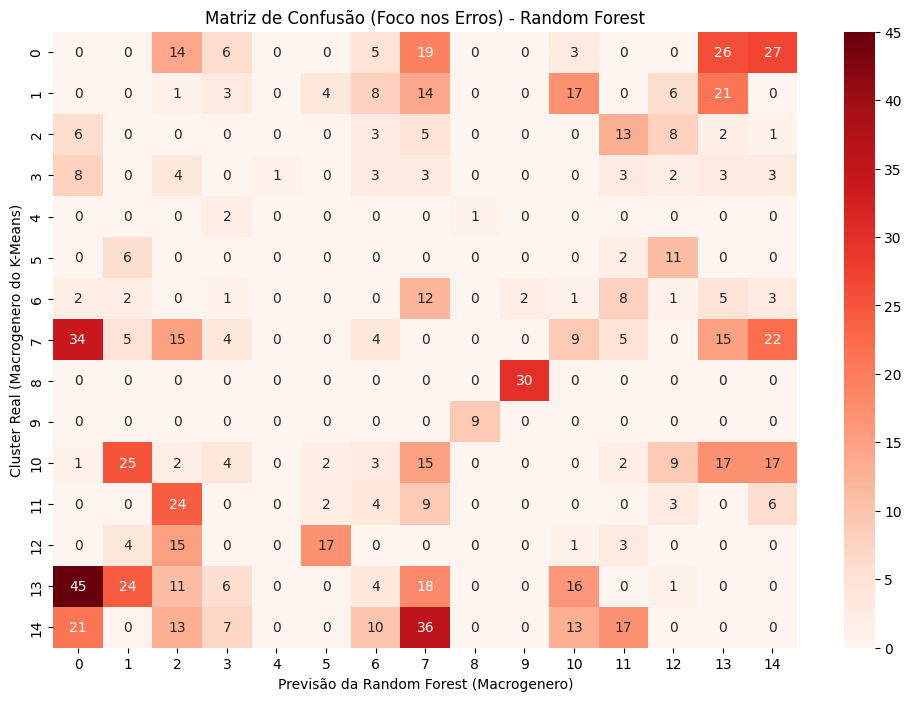

In [79]:
y_pred_rf = melhor_modelo_rf.predict(X_test)

conf_matrix_lr = confusion_matrix(y_test, y_pred_rf)

# Zerando a diagonal principal (acertos) para focar a visualização nos erros
np.fill_diagonal(conf_matrix_lr, 0)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Reds')

plt.xlabel('Previsão da Random Forest (Macrogenero)')
plt.ylabel('Cluster Real (Macrogenero do K-Means)')
plt.title('Matriz de Confusão (Foco nos Erros) - Random Forest')
plt.show()

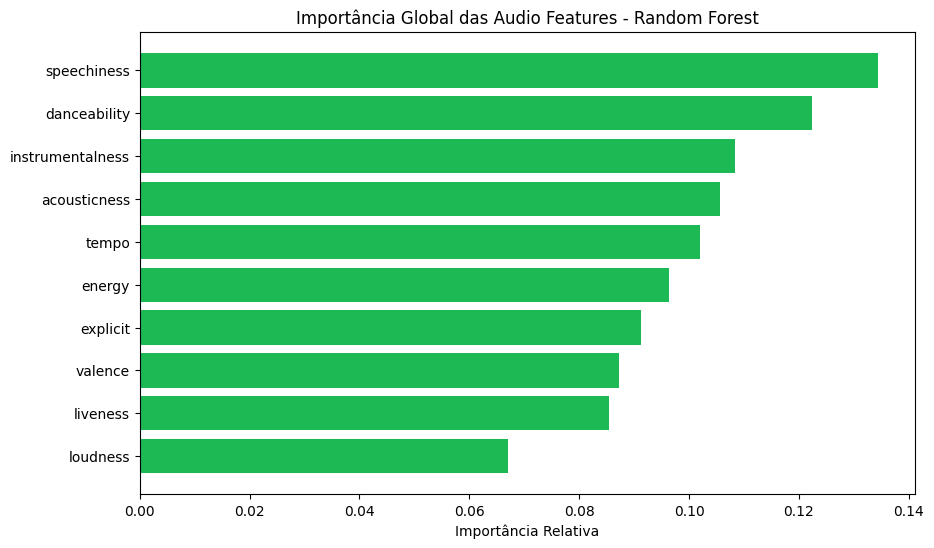

In [80]:
importancias = melhor_modelo_rf.feature_importances_

df_importancias = pd.DataFrame({
    'Feature': features, 
    'Importância': importancias
}).sort_values(by='Importância', ascending=True)

# Pegando as 10 mais relevantes
df_top_10 = df_importancias.tail(10)

plt.figure(figsize=(10, 6))
plt.barh(df_top_10['Feature'], df_top_10['Importância'], color='#1DB954')
plt.xlabel('Importância Relativa')
plt.title('Importância Global das Audio Features - Random Forest')
plt.show()

In [97]:
# 1. Garantir que a pasta existe na raiz do backend
os.makedirs("../backend/models/rf", exist_ok=True)

# 2. Salvar o Modelo Roteador (A Fase 1)
# Alterei o nome do arquivo para algo mais genérico, já que pode ser um K-Means ou LightGBM
caminho_roteador = "../backend/models/rf/rf_macrogenero.pkl"

joblib.dump(melhor_modelo_rf, caminho_roteador)

print(f"Roteador salvo em: {caminho_roteador}")

# 3. Salvar os Pacotes Especialistas (A Fase 2: Modelo + Scaler)
print("Salvando os Especialistas (Regressão Logística)...")
for vibe, info_especialista in especialistas.items():
    # Boa prática: limpar o nome da vibe para evitar erros de formatação no Windows/Linux
    nome_arquivo_vibe = str(vibe).replace(" ", "_").replace("/", "_")
    caminho_especialista = f"../backend/models/rf/rf_especialista_{nome_arquivo_vibe}.pkl"
    
    # O joblib salva o dicionário inteiro perfeitamente!
    joblib.dump(info_especialista, caminho_especialista)
    print(f" -> Salvo: {caminho_especialista}")

print(f"\nTodos os {len(especialistas)} pacotes de especialistas foram salvos com sucesso e estão prontos para o FastAPI!")

Roteador salvo em: ../backend/models/rf/rf_macrogenero.pkl
Salvando os Especialistas (Regressão Logística)...
 -> Salvo: ../backend/models/rf/rf_especialista_0.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_1.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_10.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_13.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_7.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_14.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_6.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_9.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_12.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_5.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_2.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_3.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_8.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_11.pkl
 -> Salvo: ../backend/models/rf/rf_especialista_4.pkl

Todos os 15 pacotes de especialistas foram salvos com sucesso e estão pron